<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/06_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/06_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 - Final Model Evaluation

**Objective:** evaluate the model selected in Week 7 on the untouched June 2026 test set and translate prediction error into practical guidance for pricing review.

This notebook does not tune models or change features. It measures generalization, identifies reliable and high-risk segments, and produces the final evaluation artifacts.


## Fixed evaluation window

| Split | Period |
|---|---|
| Train | May 2025-April 2026 |
| Validation | May 2026 |
| Test | June 2026 |

Keeping these periods fixed makes the old-vs-new feature comparison interpretable.


In [ ]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass

sns.set_theme(style='whitegrid')


Mounted at /content/drive


## 1. Load the fixed June-test split


In [ ]:
OUTPUT_DIR = Path(os.getenv('IDX_OUTPUT_DIR', '/content/drive/MyDrive/IDX Exchange/outputs'))
DISTRICT_PATH = Path(os.getenv('IDX_DISTRICT_PATH', '/content/drive/MyDrive/IDX Exchange/DistrictAreas.geojson'))
FEATURE_DIR = OUTPUT_DIR / 'feature_engineering'
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'train': OUTPUT_DIR / 'crmls_sfr_train_X12_2025-05_to_2026-04.csv',
    'validation': OUTPUT_DIR / 'crmls_sfr_validation_2026-05.csv',
    'test': OUTPUT_DIR / 'crmls_sfr_test_2026-06.csv',
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 02 with June data first. Missing: ' + ', '.join(missing))

frames = {name: pd.read_csv(path, low_memory=False) for name, path in paths.items()}
for name, frame in frames.items():
    print(name, frame.shape, paths[name].name)


train (118774, 155) crmls_sfr_train_X12_2025-05_to_2026-04.csv
validation (11984, 155) crmls_sfr_validation_2026-05.csv
test (12827, 155) crmls_sfr_test_2026-06.csv


## 2. Define old and new features

The old feature set represents information available before Week 6. The new set adds ratios, property age, amenity density, seasonal context, and an independently sourced school-district layer.


In [ ]:
TARGET = 'ClosePrice'
OLD_NUMERIC = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet',
    'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'Latitude', 'Longitude',
]
OLD_CATEGORICAL = ['City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor']
AMENITY_COLUMNS = [
    'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
    'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN',
]
NEW_NUMERIC = [
    'BedBathRatio', 'PropertyAge', 'LivingAreaToLotRatio',
    'AmenitiesCount', 'CloseMonthSin', 'CloseMonthCos',
]
NEW_CATEGORICAL = ['DistrictName']

required = set(OLD_NUMERIC + OLD_CATEGORICAL + AMENITY_COLUMNS + [TARGET, 'CloseDate'])
for name, frame in frames.items():
    missing_columns = sorted(required - set(frame.columns))
    if missing_columns:
        raise KeyError(f'{name} is missing required fields: {missing_columns}')


## 3. Engineer property-level features


In [ ]:
TRUE_VALUES = {'true', 't', 'yes', 'y', '1'}

def add_property_features(frame):
    result = frame.copy()
    close_date = pd.to_datetime(result['CloseDate'], errors='coerce')
    bedrooms = pd.to_numeric(result['BedroomsTotal'], errors='coerce')
    bathrooms = pd.to_numeric(result['BathroomsTotalInteger'], errors='coerce')
    living_area = pd.to_numeric(result['LivingArea'], errors='coerce')
    lot_size = pd.to_numeric(result['LotSizeSquareFeet'], errors='coerce')
    year_built = pd.to_numeric(result['YearBuilt'], errors='coerce')

    result['BedBathRatio'] = bedrooms / bathrooms.where(bathrooms > 0)
    result['PropertyAge'] = (close_date.dt.year - year_built).clip(lower=0, upper=250)
    result['LivingAreaToLotRatio'] = living_area / lot_size.where(lot_size > 0)
    result['CloseMonthSin'] = np.sin(2 * np.pi * close_date.dt.month / 12)
    result['CloseMonthCos'] = np.cos(2 * np.pi * close_date.dt.month / 12)

    amenity_values = pd.DataFrame(index=result.index)
    for column in AMENITY_COLUMNS:
        amenity_values[column] = (
            result[column].astype(str).str.strip().str.lower().isin(TRUE_VALUES).astype(int)
        )
        result[column] = amenity_values[column]
    result['AmenitiesCount'] = amenity_values.sum(axis=1)
    return result

engineered = {name: add_property_features(frame) for name, frame in frames.items()}
engineered['train'][NEW_NUMERIC].describe().T


,count,mean,std,min,25%,50%,75%,max
BedBathRatio,118736.0,1.458686,0.473016,0.00000,1.000000,1.500000e+00,1.500000,7.500000
PropertyAge,118774.0,49.868751,27.433623,0.00000,28.000000,5.000000e+01,70.000000,225.000000
LivingAreaToLotRatio,118774.0,20.957632,595.966240,0.00016,0.167639,2.364113e-01,0.333391,60566.666667
AmenitiesCount,118774.0,2.232383,1.021722,0.00000,2.000000,2.000000e+00,3.000000,6.000000
CloseMonthSin,118774.0,-0.064696,0.723986,-1.00000,-0.866025,-2.449294e-16,0.500000,1.000000
CloseMonthCos,118774.0,-0.113508,0.677335,-1.00000,-0.866025,-1.836970e-16,0.500000,1.000000


## 4. Spatially join California school districts


In [ ]:
if not DISTRICT_PATH.exists():
    raise FileNotFoundError(f'School-district boundary file not found: {DISTRICT_PATH}')

districts = gpd.read_file(DISTRICT_PATH)
if districts.crs is None:
    raise ValueError('The school-district boundary file has no CRS metadata.')

name_candidates = [
    'DistrictName', 'DISTRICT', 'NAME', 'Name', 'district',
    'LEA_NAME', 'UNIFIED', 'SchoolDistrict',
]
district_name_column = next((column for column in name_candidates if column in districts.columns), None)
if district_name_column is None:
    text_columns = [column for column in districts.columns if column != 'geometry' and districts[column].dtype == 'object']
    if not text_columns:
        raise KeyError('Could not identify a district-name column in the boundary file.')
    district_name_column = text_columns[0]

district_lookup = districts[[district_name_column, 'geometry']].rename(columns={district_name_column: 'DistrictName'})

def add_school_district(frame):
    valid_coordinates = frame['Latitude'].notna() & frame['Longitude'].notna()
    result = frame.copy()
    result['DistrictName'] = 'Unknown District'
    points = gpd.GeoDataFrame(
        result.loc[valid_coordinates, ['Latitude', 'Longitude']].copy(),
        geometry=gpd.points_from_xy(
            result.loc[valid_coordinates, 'Longitude'],
            result.loc[valid_coordinates, 'Latitude'],
        ),
        crs='EPSG:4326',
    ).to_crs(district_lookup.crs)
    joined = gpd.sjoin(points, district_lookup, how='left', predicate='within')
    district_values = joined.groupby(level=0)['DistrictName'].first().fillna('Unknown District')
    result.loc[district_values.index, 'DistrictName'] = district_values
    return result

engineered = {name: add_school_district(frame) for name, frame in engineered.items()}

coverage = pd.DataFrame([
    {
        'Split': name,
        'Rows': len(frame),
        'MatchedDistrictRows': int(frame['DistrictName'].ne('Unknown District').sum()),
        'MatchRate_pct': frame['DistrictName'].ne('Unknown District').mean() * 100,
        'UniqueDistricts': frame.loc[frame['DistrictName'].ne('Unknown District'), 'DistrictName'].nunique(),
    }
    for name, frame in engineered.items()
])
display(coverage.style.format({'MatchRate_pct': '{:.2f}%'}))


,Split,Rows,MatchedDistrictRows,MatchRate_pct,UniqueDistricts
0,train,118774,118760,99.99%,594
1,validation,11984,11984,100.00%,455
2,test,12827,12827,100.00%,447


## 5. Load the Week 7 selected model

The saved artifact records the model selected using May validation MdAPE. June test outcomes were not used for hyperparameter tuning or model-family selection.


In [ ]:
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ADVANCED_DIR = OUTPUT_DIR / 'advanced_models'
MODEL_PATH = ADVANCED_DIR / 'selected_advanced_model.joblib'
if not MODEL_PATH.exists():
    raise FileNotFoundError('Run 05_advanced_models.ipynb first: ' + str(MODEL_PATH))

try:
    model_bundle = joblib.load(MODEL_PATH)
except (ImportError, OSError) as error:
    raise ImportError(
        'The selected artifact requires its training libraries. In Colab, install xgboost and restart the runtime.'
    ) from error

selected_model_name = model_bundle['model_name']
selected_model = model_bundle['model']
numeric_features = model_bundle['numeric_features']
categorical_features = model_bundle['categorical_features']
model_features = numeric_features + categorical_features
print('Selected model:', selected_model_name)
evaluation_bounds = model_bundle['evaluation_bounds']
print('Input features:', len(model_features))
print('Using train-defined primary-population bounds:', evaluation_bounds)


Selected model: Random Forest
Input features: 39
Using train-defined primary-population bounds: {'closeprice_p005_train': 190000.0, 'closeprice_p995_train': 8750000.0, 'price_per_sqft_p005_train': 163.53383935969939, 'price_per_sqft_p995_train': 2126.9181463498408}


## 6. Generate locked validation and test predictions


In [ ]:
def valid_target_rows(frame):
    result = frame.copy()
    result[TARGET] = pd.to_numeric(result[TARGET], errors='coerce')
    return result[result[TARGET].notna() & result[TARGET].gt(0)].copy()

full_validation_eval = valid_target_rows(engineered['validation'])
full_test_eval = valid_target_rows(engineered['test'])

def primary_population_mask(frame):
    living_area = pd.to_numeric(frame['LivingArea'], errors='coerce')
    ppsf = frame[TARGET] / living_area.where(living_area > 0)
    return (
        frame[TARGET].between(
            evaluation_bounds['closeprice_p005_train'],
            evaluation_bounds['closeprice_p995_train'],
        )
        & (ppsf.isna() | ppsf.between(
            evaluation_bounds['price_per_sqft_p005_train'],
            evaluation_bounds['price_per_sqft_p995_train'],
        ))
    )

validation_eval = full_validation_eval.loc[primary_population_mask(full_validation_eval)].copy()
test_eval = full_test_eval.loc[primary_population_mask(full_test_eval)].copy()

for frame in [validation_eval, test_eval, full_test_eval]:
    frame['PredictedClosePrice'] = selected_model.predict(frame[model_features])
    frame['Residual'] = frame[TARGET] - frame['PredictedClosePrice']
    frame['AbsoluteError'] = frame['Residual'].abs()
    frame['AbsolutePercentageError'] = frame['AbsoluteError'] / frame[TARGET] * 100
    frame['PredictionRatio'] = frame['PredictedClosePrice'] / frame[TARGET]

print('Primary validation rows:', len(validation_eval), 'of', len(full_validation_eval))
print('Primary test rows:', len(test_eval), 'of', len(full_test_eval))


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Primary validation rows: 11735 of 11984
Primary test rows: 12543 of 12827


## 7. Overall performance and temporal stability


In [ ]:
def metrics(frame):
    actual = frame[TARGET]
    predicted = frame['PredictedClosePrice']
    return {
        'R2': r2_score(actual, predicted),
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'MAPE_pct': frame['AbsolutePercentageError'].mean(),
        'MdAPE_pct': frame['AbsolutePercentageError'].median(),
        'Within10Pct_pct': frame['AbsolutePercentageError'].le(10).mean() * 100,
        'Within20Pct_pct': frame['AbsolutePercentageError'].le(20).mean() * 100,
        'Within30Pct_pct': frame['AbsolutePercentageError'].le(30).mean() * 100,
    }

overall = pd.DataFrame([
    {'Model': selected_model_name, 'Split': 'Validation', 'Rows': len(validation_eval), **metrics(validation_eval)},
    {'Model': selected_model_name, 'Split': 'Test - Primary In-Range', 'Rows': len(test_eval), **metrics(test_eval)},
    {'Model': selected_model_name, 'Split': 'Full Test Robustness', 'Rows': len(full_test_eval), **metrics(full_test_eval)},
])
display(overall.style.format({
    'R2': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
    'Within10Pct_pct': '{:.1f}%', 'Within20Pct_pct': '{:.1f}%', 'Within30Pct_pct': '{:.1f}%',
}))

stability_fields = ['R2', 'MAE', 'RMSE', 'MAPE_pct', 'MdAPE_pct']
stability_table = overall.set_index('Split')[stability_fields]
stability = stability_table.loc['Test - Primary In-Range'] - stability_table.loc['Validation']
print(f"Validation-to-test R² change: {stability['R2']:+.4f}")
print(f"Validation-to-test MdAPE change: {stability['MdAPE_pct']:+.2f} percentage points")


,Model,Split,Rows,R2,MAE,RMSE,MAPE_pct,MdAPE_pct,Within10Pct_pct,Within20Pct_pct,Within30Pct_pct
0,Random Forest,Validation,11735,0.8757,"$171,103","$334,436",12.72%,8.20%,57.2%,81.3%,91.0%
1,Random Forest,Test - Primary In-Range,12543,0.8762,"$170,135","$335,700",12.77%,8.23%,57.5%,81.1%,90.7%
2,Random Forest,Full Test Robustness,12827,0.5999,"$231,306","$955,058",22.72%,8.48%,56.3%,79.4%,88.9%


Validation-to-test R² change: +0.0004
Validation-to-test MdAPE change: +0.03 percentage points


## 8. Actual versus predicted and residual diagnostics


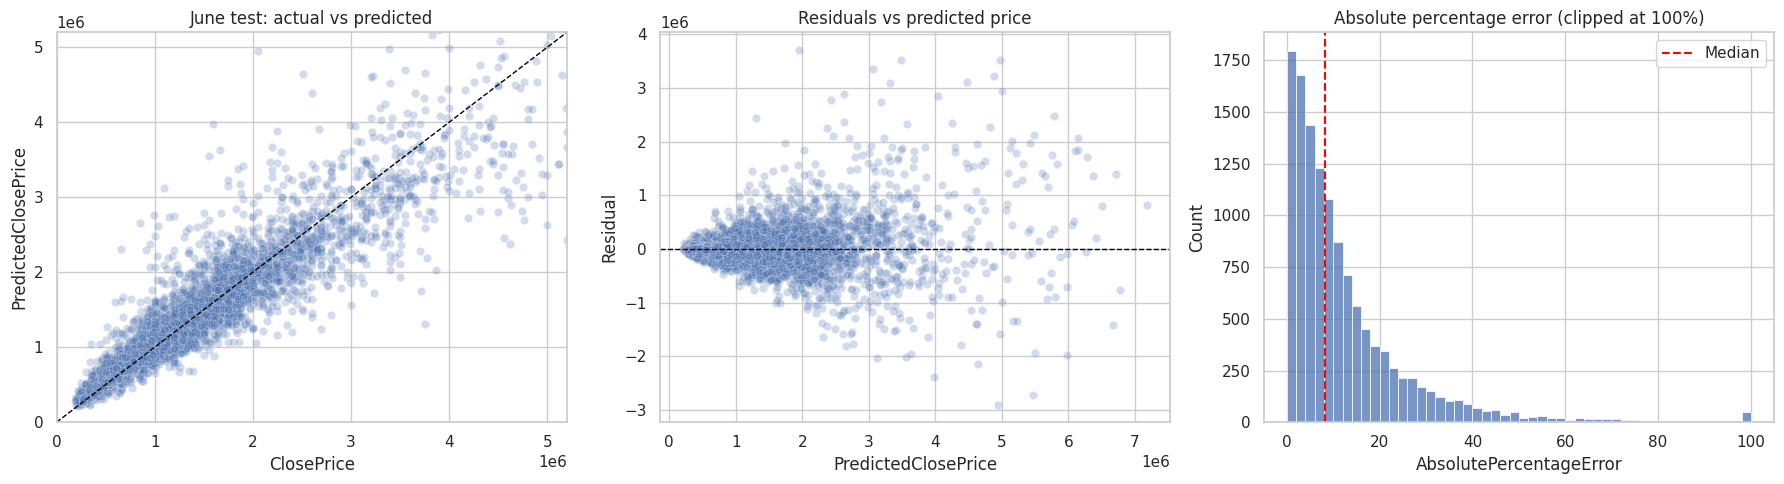

In [ ]:
plot_sample = test_eval.sample(min(8_000, len(test_eval)), random_state=42)
figure, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=plot_sample, x=TARGET, y='PredictedClosePrice', alpha=0.25, ax=axes[0])
limit = max(plot_sample[TARGET].quantile(.99), plot_sample['PredictedClosePrice'].quantile(.99))
axes[0].plot([0, limit], [0, limit], '--', color='black', linewidth=1)
axes[0].set(xlim=(0, limit), ylim=(0, limit), title='June test: actual vs predicted')

sns.scatterplot(data=plot_sample, x='PredictedClosePrice', y='Residual', alpha=0.25, ax=axes[1])
axes[1].axhline(0, linestyle='--', color='black', linewidth=1)
axes[1].set_title('Residuals vs predicted price')

sns.histplot(test_eval['AbsolutePercentageError'].clip(upper=100), bins=50, ax=axes[2])
axes[2].axvline(test_eval['AbsolutePercentageError'].median(), color='red', linestyle='--', label='Median')
axes[2].set_title('Absolute percentage error (clipped at 100%)')
axes[2].legend()
plt.tight_layout()
plt.show()


## 9. Performance by price band


In [ ]:
price_edges = [0, 500_000, 750_000, 1_000_000, 1_500_000, 2_000_000, np.inf]
price_labels = ['Under $500K', '$500K-$750K', '$750K-$1M', '$1M-$1.5M', '$1.5M-$2M', '$2M+']
test_eval['PriceBand'] = pd.cut(test_eval[TARGET], bins=price_edges, labels=price_labels, right=False)

price_band_summary = (
    test_eval.groupby('PriceBand', observed=True)
    .agg(
        Rows=(TARGET, 'size'),
        MedianActualPrice=(TARGET, 'median'),
        MAE=('AbsoluteError', 'mean'),
        MAPE_pct=('AbsolutePercentageError', 'mean'),
        MdAPE_pct=('AbsolutePercentageError', 'median'),
        MedianBias=('Residual', 'median'),
        Within20Pct_pct=('AbsolutePercentageError', lambda values: values.le(20).mean() * 100),
    )
    .reset_index()
)
display(price_band_summary.style.format({
    'MedianActualPrice': '${:,.0f}', 'MAE': '${:,.0f}', 'MedianBias': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%', 'Within20Pct_pct': '{:.1f}%',
}))


,PriceBand,Rows,MedianActualPrice,MAE,MAPE_pct,MdAPE_pct,MedianBias,Within20Pct_pct
0,Under $500K,1634,"$405,000","$58,118",15.69%,8.55%,"$-18,532",74.7%
1,$500K-$750K,2679,"$625,000","$65,822",10.66%,6.05%,"$-12,624",85.3%
2,$750K-$1M,2611,"$860,000","$87,917",10.10%,6.50%,"$-11,016",87.9%
3,$1M-$1.5M,2568,"$1,215,000","$159,778",13.06%,9.18%,"$5,999",82.7%
4,$1.5M-$2M,1402,"$1,690,000","$239,390",14.01%,10.12%,"$24,854",79.7%
5,$2M+,1649,"$2,725,000","$538,028",16.07%,13.31%,"$240,652",68.7%


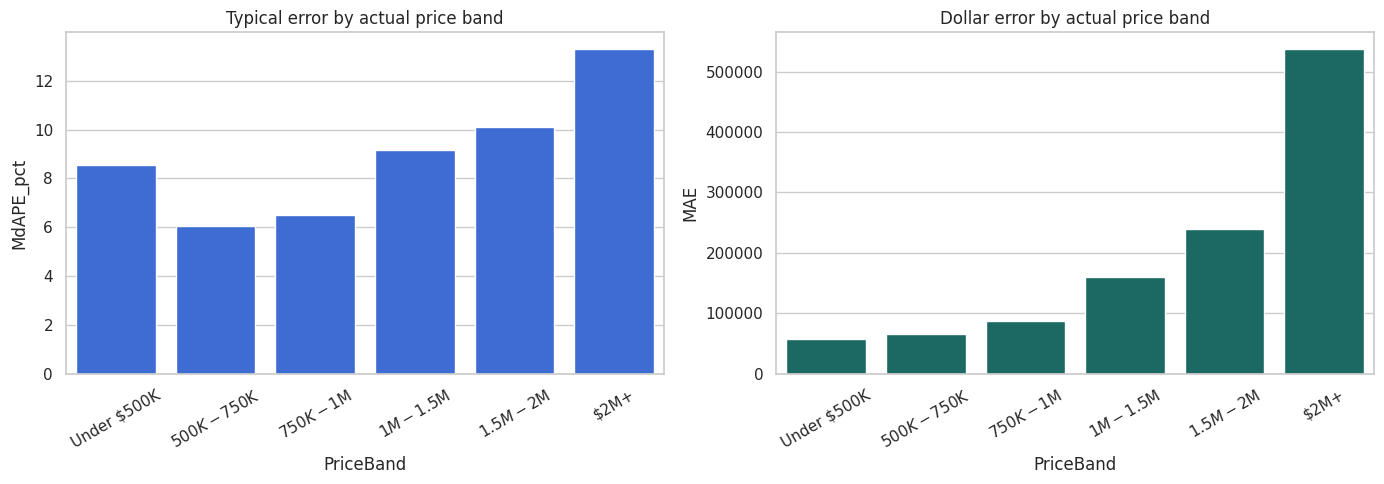

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=price_band_summary, x='PriceBand', y='MdAPE_pct', color='#2563eb', ax=axes[0])
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Typical error by actual price band')
sns.barplot(data=price_band_summary, x='PriceBand', y='MAE', color='#0f766e', ax=axes[1])
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Dollar error by actual price band')
plt.tight_layout()
plt.show()


## 10. Geographic reliability

County summaries are reported only when the June test set contains at least 100 transactions. Smaller samples are too unstable for stakeholder conclusions.


In [ ]:
county_summary = (
    test_eval.groupby('CountyOrParish', dropna=False)
    .agg(
        Rows=(TARGET, 'size'),
        MedianActualPrice=(TARGET, 'median'),
        MAE=('AbsoluteError', 'mean'),
        MAPE_pct=('AbsolutePercentageError', 'mean'),
        MdAPE_pct=('AbsolutePercentageError', 'median'),
        MedianBias=('Residual', 'median'),
    )
    .reset_index()
)
county_summary = county_summary[county_summary['Rows'].ge(100)].sort_values('MdAPE_pct')
display(county_summary.style.format({
    'MedianActualPrice': '${:,.0f}', 'MAE': '${:,.0f}', 'MedianBias': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
}))


,CountyOrParish,Rows,MedianActualPrice,MAE,MAPE_pct,MdAPE_pct,MedianBias
19,Merced,107,"$435,000","$59,558",10.84%,5.44%,"$-2,095"
26,Riverside,1941,"$635,000","$87,043",9.99%,6.03%,"$-4,521"
29,San Bernardino,1229,"$555,000","$61,629",10.02%,6.15%,$-992
48,Ventura,449,"$930,000","$175,155",12.33%,7.78%,"$-23,595"
10,Kern,124,"$415,000","$77,936",15.28%,7.86%,"$-4,349"
30,San Diego,1442,"$1,100,000","$178,092",11.35%,8.04%,"$4,334"
23,Orange,1199,"$1,449,000","$212,373",10.83%,8.34%,"$17,743"
5,Contra Costa,630,"$947,000","$166,520",12.19%,8.51%,"$-1,024"
2,Butte,166,"$446,500","$83,786",14.05%,9.29%,"$-12,300"
14,Los Angeles,3014,"$1,050,000","$212,303",13.96%,9.59%,"$-6,680"


## 11. Overprediction, underprediction, and review thresholds


In [ ]:
direction_summary = pd.DataFrame([
    {
        'Direction': 'Underprediction',
        'Rows': int(test_eval['Residual'].gt(0).sum()),
        'Share_pct': test_eval['Residual'].gt(0).mean() * 100,
        'MedianDollarError': test_eval.loc[test_eval['Residual'].gt(0), 'Residual'].median(),
    },
    {
        'Direction': 'Overprediction',
        'Rows': int(test_eval['Residual'].lt(0).sum()),
        'Share_pct': test_eval['Residual'].lt(0).mean() * 100,
        'MedianDollarError': test_eval.loc[test_eval['Residual'].lt(0), 'Residual'].median(),
    },
])
display(direction_summary.style.format({'Share_pct': '{:.1f}%', 'MedianDollarError': '${:,.0f}'}))

test_eval['ReviewPriority'] = pd.cut(
    test_eval['AbsolutePercentageError'],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=['Low', 'Moderate', 'High', 'Critical'],
)
review_summary = test_eval['ReviewPriority'].value_counts(sort=False).rename_axis('ReviewPriority').reset_index(name='Rows')
review_summary['Share_pct'] = review_summary['Rows'] / len(test_eval) * 100
display(review_summary.style.format({'Share_pct': '{:.1f}%'}))


,Direction,Rows,Share_pct,MedianDollarError
0,Underprediction,6011,47.9%,"$71,992"
1,Overprediction,6532,52.1%,"$-79,217"


,ReviewPriority,Rows,Share_pct
0,Low,7215,57.5%
1,Moderate,2962,23.6%
2,High,1201,9.6%
3,Critical,1165,9.3%


## 12. Largest-error case review

The diagnostic table intentionally excludes exact addresses, listing IDs, and agent information. It is for identifying recurring model failure patterns, not exposing individual records.


In [ ]:
diagnostic_columns = [
    'City', 'CountyOrParish', 'PostalCode', 'DistrictName',
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'PropertyAge',
    TARGET, 'PredictedClosePrice', 'AbsoluteError', 'AbsolutePercentageError',
]
available_diagnostic_columns = [column for column in diagnostic_columns if column in test_eval.columns]
largest_errors = test_eval.nlargest(25, 'AbsolutePercentageError')[available_diagnostic_columns]
display(largest_errors.style.format({
    TARGET: '${:,.0f}', 'PredictedClosePrice': '${:,.0f}',
    'AbsoluteError': '${:,.0f}', 'AbsolutePercentageError': '{:.1f}%',
}))


,City,CountyOrParish,PostalCode,DistrictName,LivingArea,BedroomsTotal,BathroomsTotalInteger,PropertyAge,ClosePrice,PredictedClosePrice,AbsoluteError,AbsolutePercentageError
8300,Pine Mountain Club,Kern,93225,El Tejon Unified,3716.000000,4.000000,5.000000,21.000000,"$659,000","$2,306,490","$1,647,490",250.0%
2970,Philo,Mendocino,95466,Anderson Valley Unified,600.000000,0.000000,1.000000,13.000000,"$199,849","$679,053","$479,204",239.8%
9798,Canyon Lake,Riverside,92587,Lake Elsinore Unified,4341.000000,4.000000,5.000000,43.000000,"$850,000","$2,660,485","$1,810,485",213.0%
9231,Jackson,Amador,95642,Amador County Unified,3833.000000,7.000000,6.000000,120.000000,"$847,500","$2,646,838","$1,799,338",212.3%
302,Paso Robles,San Luis Obispo,93446,Paso Robles Joint Unified,1736.000000,2.000000,1.000000,50.000000,"$350,000","$1,043,544","$693,544",198.2%
9703,San Pedro,Los Angeles,90731,Los Angeles Unified,2204.000000,4.000000,3.000000,50.000000,"$480,000","$1,429,309","$949,309",197.8%
5890,Los Angeles,Los Angeles,90046,Los Angeles Unified,5100.000000,8.000000,4.000000,105.000000,"$1,375,000","$3,976,215","$2,601,215",189.2%
7831,Chico,Butte,95928,Chico Unified,7073.000000,4.000000,5.000000,21.000000,"$1,495,000","$4,277,829","$2,782,829",186.1%
5728,Lompoc,Santa Barbara,93436,Lompoc Unified,3380.000000,3.000000,4.000000,49.000000,"$1,100,384","$3,124,607","$2,024,223",184.0%
306,Oakland,Alameda,94610,Oakland Unified,3426.000000,4.000000,5.000000,2.000000,"$1,550,000","$4,378,781","$2,828,781",182.5%


## 13. Save final evaluation deliverables


In [ ]:
EVALUATION_DIR = OUTPUT_DIR / 'evaluation'
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

overall.to_csv(EVALUATION_DIR / 'metrics_summary.csv', index=False)
price_band_summary.to_csv(EVALUATION_DIR / 'metrics_by_price_band.csv', index=False)
county_summary.to_csv(EVALUATION_DIR / 'metrics_by_county.csv', index=False)
review_summary.to_csv(EVALUATION_DIR / 'review_priority_summary.csv', index=False)

safe_prediction_columns = [
    TARGET, 'PredictedClosePrice', 'Residual', 'AbsoluteError',
    'AbsolutePercentageError', 'PriceBand', 'ReviewPriority',
]

# Add PriceBand and ReviewPriority to full_test_eval
full_test_eval['PriceBand'] = pd.cut(full_test_eval[TARGET], bins=price_edges, labels=price_labels, right=False)
full_test_eval['ReviewPriority'] = pd.cut(
    full_test_eval['AbsolutePercentageError'],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=['Low', 'Moderate', 'High', 'Critical'],
)

test_eval[safe_prediction_columns].to_csv(EVALUATION_DIR / 'test_predictions_anonymized.csv', index=False)
full_test_eval[safe_prediction_columns].to_csv(EVALUATION_DIR / 'full_test_predictions_robustness.csv', index=False)
print('Saved final evaluation deliverables to:', EVALUATION_DIR)

Saved final evaluation deliverables to: /content/drive/MyDrive/IDX Exchange/outputs/evaluation


## Stakeholder interpretation

1. Use the model as a first-pass pricing review tool, not as a formal appraisal.
2. Prioritize manual review when predicted and proposed prices differ by more than 20%.
3. Apply additional caution to price bands and counties with elevated MdAPE or limited sample size.
4. Review luxury and unusual properties with local comparable sales because absolute errors grow with price.
5. Monitor validation-to-test drift monthly and retrain when typical error rises materially.

### Limitations

- The evaluation covers one final test month; additional future-month backtests are needed before production use.
- MLS fields may be missing, inconsistently reported, or unavailable for properties that are not currently listed.
- School-district membership is geographic context and must not be interpreted as school quality or causal value.
- Error metrics describe historical closed sales and do not guarantee an individual transaction price.
